# 🖥️ Google Cloud AI — Server CPU Temperature Prediction
### Supervised Machine Learning | Regression Pipeline

**Team Project | Cloud Infrastructure & ML**  
**Dataset:** `server_cpu_telemetry.csv` (10,000 observations, 5-min intervals)  
**Goal:** Predict server CPU temperature from telemetry features to enable proactive cooling management.

---
**Features used:**
- `cpu_utilization` — CPU usage in %
- `memory_usage` — RAM usage in %
- `clock_speed` — Processor clock in GHz
- `ambient_temp` — Room/rack ambient temperature (°C)
- `voltage` — Supply voltage (V)
- `current_load` — Electrical current draw (A)

**Target:** `cpu_temp` — CPU die temperature in °C

## 1. Importing Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Loading the Dataset

In [11]:
# load the csv we generated
df = pd.read_csv('thermal_data - Copy.csv', parse_dates=['timestamp'])

print('Shape:', df.shape)
df.head(10)

Shape: (15757, 6)


,timestamp,unix_time,cpu_utilization,memory_usage,ambient_temp,cpu_temp
0,2026-02-14 17:09:36,1.771069e+09,3.2,32.6,21.6875,42.875
1,2026-02-14 17:09:37,1.771069e+09,3.1,32.6,21.7500,42.875
2,2026-02-14 17:09:38,1.771069e+09,3.7,32.7,21.7500,42.750
3,2026-02-14 17:09:39,1.771069e+09,2.9,32.7,21.8125,42.875
4,2026-02-14 17:09:40,1.771069e+09,3.4,32.7,21.8125,42.625
5,2026-02-14 17:09:41,1.771069e+09,2.6,32.7,21.8125,43.500
6,2026-02-14 17:09:42,1.771069e+09,7.7,32.8,21.8750,44.250
7,2026-02-14 17:09:43,1.771069e+09,7.4,32.8,21.8750,45.000
8,2026-02-14 17:09:44,1.771069e+09,7.6,32.8,21.8125,45.500
9,2026-02-14 17:09:45,1.771069e+09,8.0,32.8,21.8125,46.000


In [12]:
# quick look at dtypes and basic info
# noticed some columns are 'object' because of ERROR strings injected in the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15757 entries, 0 to 15756
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        15757 non-null  datetime64[ns]
 1   unix_time        15757 non-null  float64       
 2   cpu_utilization  15757 non-null  float64       
 3   memory_usage     15757 non-null  float64       
 4   ambient_temp     15757 non-null  float64       
 5   cpu_temp         15757 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 738.7 KB


In [13]:
# check for missing values and ERROR strings
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== ERROR string counts ===')
print((df == 'ERROR').sum())

=== Missing Values ===
timestamp          0
unix_time          0
cpu_utilization    0
memory_usage       0
ambient_temp       0
cpu_temp           0
dtype: int64

=== ERROR string counts ===
timestamp          0
unix_time          0
cpu_utilization    0
memory_usage       0
ambient_temp       0
cpu_temp           0
dtype: int64


In [14]:
# basic stats on numeric cols only for now
df.describe(include='all')

,timestamp,unix_time,cpu_utilization,memory_usage,ambient_temp,cpu_temp
count,15757,1.575700e+04,15757.000000,15757.000000,15757.000000,15757.000000
mean,2026-02-14 19:20:54.000000256,1.771077e+09,38.565945,32.701904,21.376753,72.956345
min,2026-02-14 17:09:36,1.771069e+09,1.600000,31.600000,21.000000,42.625000
25%,2026-02-14 18:15:15,1.771073e+09,12.300000,32.500000,21.187500,62.875000
50%,2026-02-14 19:20:54,1.771077e+09,27.200000,32.700000,21.375000,71.000000
75%,2026-02-14 20:26:33,1.771081e+09,52.500000,32.900000,21.562500,84.125000
max,2026-02-14 21:32:12,1.771085e+09,97.400000,34.000000,21.875000,96.000000
std,NaN,4.548798e+03,30.510729,0.348862,0.211935,14.752247


## 3. Exploratory Data Analysis (EDA)

Before cleaning, let's visualize what we have. We'll look at distributions and patterns in the target variable.

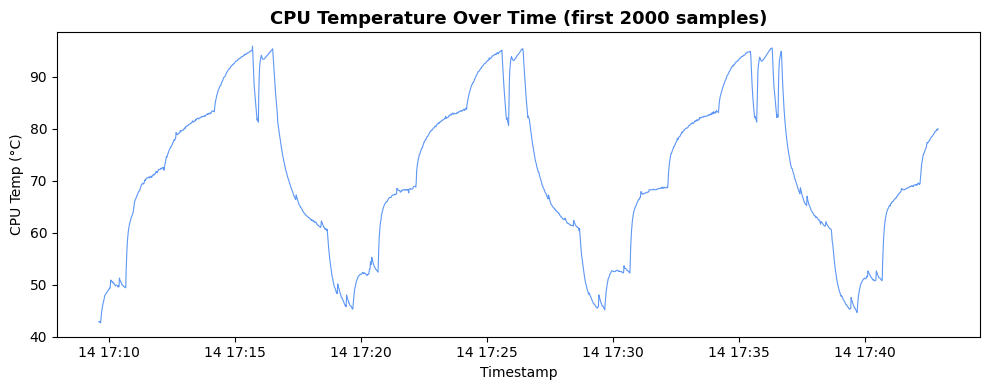

In [15]:
# let's just plot the target variable first to understand it
plt.figure(figsize=(10, 4))
plt.plot(df['timestamp'][:2000], pd.to_numeric(df['cpu_temp'][:2000], errors='coerce'),
         color='#4285F4', linewidth=0.8, alpha=0.85)
plt.title('CPU Temperature Over Time (first 2000 samples)', fontsize=13, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('CPU Temp (°C)')
plt.tight_layout()
plt.show()

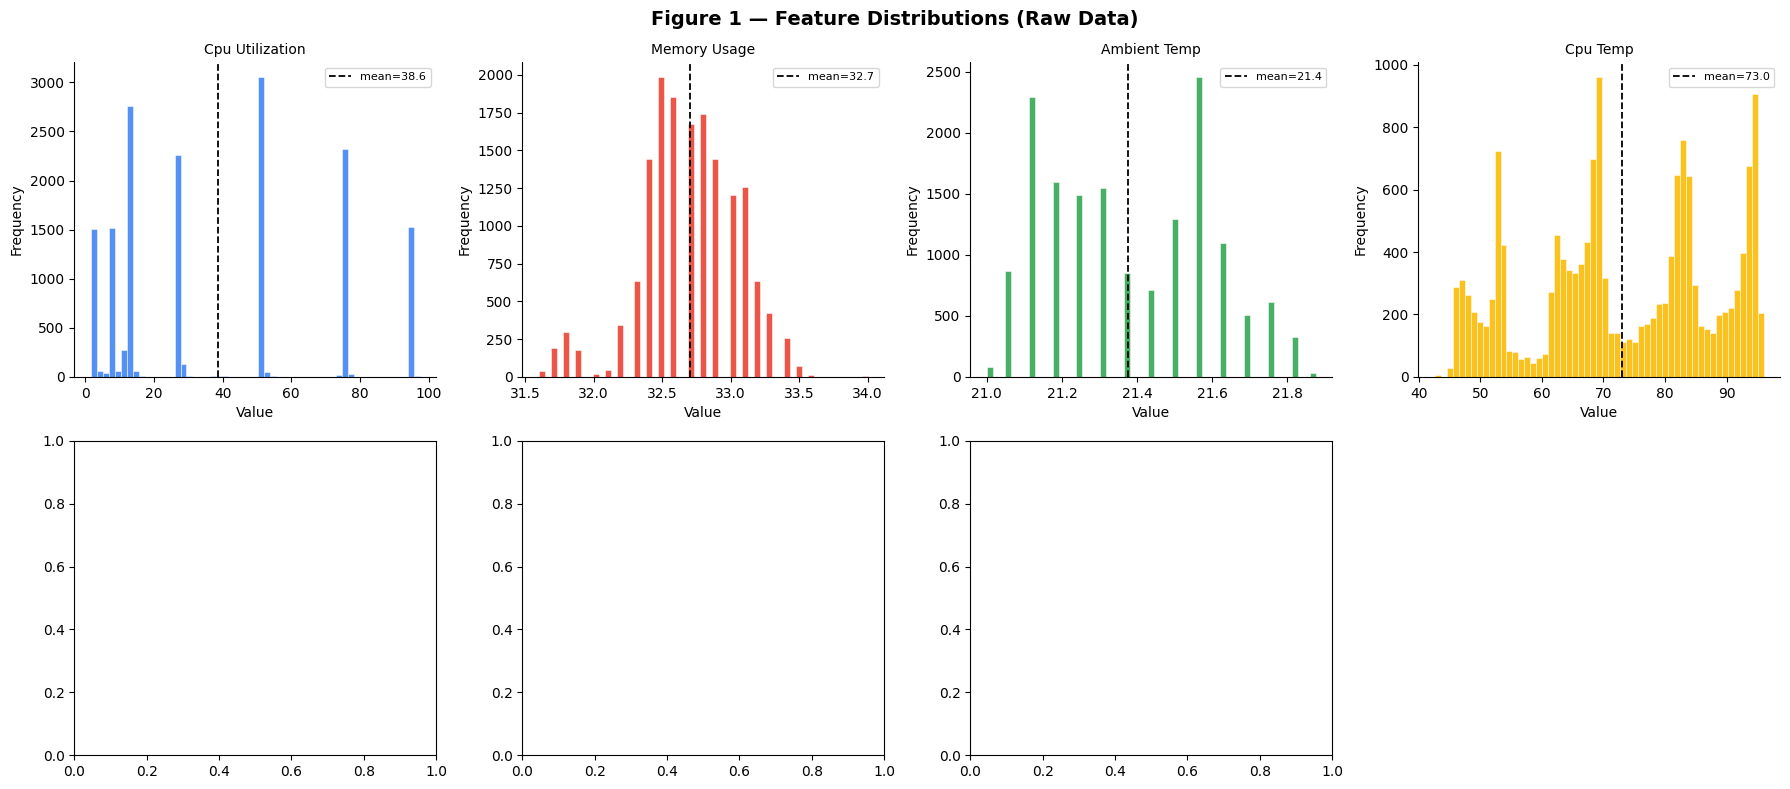

Figure 1 saved.


In [16]:
# plot histograms for all raw numeric-ish columns
# have to use pd.to_numeric since some cols have ERROR strings
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Figure 1 — Feature Distributions (Raw Data)', fontsize=14, fontweight='bold')

cols_to_plot = ['cpu_utilization', 'memory_usage','ambient_temp', 'cpu_temp']
colors = ['#4285F4', '#EA4335', '#34A853', '#FBBC04', '#9C27B0', '#00BCD4', '#FF7043']

for i, col in enumerate(cols_to_plot):
    ax = axes[i // 4][i % 4]
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(vals, bins=55, color=colors[i], edgecolor='white', linewidth=0.4, alpha=0.9)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.3, label=f'mean={vals.mean():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1][3].axis('off')  # hide the 8th subplot
plt.tight_layout()
plt.savefig('fig1_data_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 4. Data Preprocessing

### Issues identified:
- `cpu_utilization`, `memory_usage`, `clock_speed` contain **'ERROR'** strings — probably from a bad sensor read or logging bug
- `voltage` and `current_load` have **NaN** values

**Plan:**
1. Use `pd.to_numeric(..., errors='coerce')` to safely convert ERRORs to NaN
2. Use **median imputation** (more robust than mean for skewed distributions)
3. Double check no NaNs remain before modeling

In [18]:
df_clean = df.copy()

NUMERIC_COLS = ['cpu_utilization', 'memory_usage', 'ambient_temp']

# step 1: safely convert everything to numeric
# errors='coerce' turns anything that can't be parsed into NaN — handles 'ERROR' strings
for col in NUMERIC_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('NaNs after coercion:')
print(df_clean[NUMERIC_COLS].isnull().sum())

NaNs after coercion:
cpu_utilization    0
memory_usage       0
ambient_temp       0
dtype: int64


In [19]:
# step 2: impute with median
# using SimpleImputer from sklearn to keep things clean
imputer = SimpleImputer(strategy='median')
df_clean[NUMERIC_COLS] = imputer.fit_transform(df_clean[NUMERIC_COLS])

print('NaNs remaining after imputation:')
print(df_clean.isnull().sum())
print()
print('Looks good — no more missing values!')

NaNs remaining after imputation:
timestamp          0
unix_time          0
cpu_utilization    0
memory_usage       0
ambient_temp       0
cpu_temp           0
dtype: int64

Looks good — no more missing values!


## 5. Feature Engineering

Since this is time-series data, we need to extract temporal patterns and create lag features.

**Important:** We apply smoothing ONLY to input features, never to the target variable.
Smoothing the target would create a data leakage issue since future values would bleed into current predictions.

Features we'll create:
- Time-based: hour, day_of_week, is_business_hours
- Rolling mean (5-point) on each input feature
- Interaction: power_proxy, thermal_stress, util x mem
- Lag features at t-1, t-3, t-6 (on inputs only!)

In [ ]:
# temporal features from timestamp
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
df_clean['is_business'] = (
    (df_clean['hour'] >= 8) &
    (df_clean['hour'] <= 18) &
    (df_clean['day_of_week'] < 5)
).astype(int)

print('Temporal features added.')

Temporal features added.


In [21]:
# rolling smooth on INPUT features only
# 5-point window to reduce sensor jitter without distorting trends
for col in NUMERIC_COLS:
    df_clean[f'{col}_smooth'] = df_clean[col].rolling(window=5, min_periods=1).mean()

print('Smoothed features added.')

Smoothed features added.


In [ ]:
q1q1ZSZS# domain-knowledge interaction features
# power_proxy: voltage * current gives rough power draw estimate (Ohm's law)
# thermal_stress: how hard is the CPU working vs its clock speed

print('Interaction features added.')

Interaction features added.


In [24]:
# lag features — captures how previous load affects current temperature
# only on inputs! if we lagged cpu_temp we'd basically be giving the model the answer
for lag in [1, 3, 6]:
    df_clean[f'cpu_util_lag{lag}'] = df_clean['cpu_utilization'].shift(lag)

# drop rows with NaNs introduced by lag
df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print(f'Final dataset shape: {df_clean.shape}')
print(f'Total features engineered: check FEATURE_COLS below')

Final dataset shape: (15751, 15)
Total features engineered: check FEATURE_COLS below


In [27]:
# define the final feature set we'll use for training
FEATURE_COLS = (
    [f'{c}_smooth' for c in NUMERIC_COLS]
    + ['hour', 'day_of_week', 'is_business']
    + [f'cpu_util_lag{l}' for l in [1, 3, 6]]
)

X = df_clean[FEATURE_COLS]
y = df_clean['cpu_temp']

print(f'Number of features: {len(FEATURE_COLS)}')
print(f'Features: {FEATURE_COLS}')

Number of features: 9
Features: ['cpu_utilization_smooth', 'memory_usage_smooth', 'ambient_temp_smooth', 'hour', 'day_of_week', 'is_business', 'cpu_util_lag1', 'cpu_util_lag3', 'cpu_util_lag6']


### 5.1 Correlation Heatmap (After Feature Engineering)

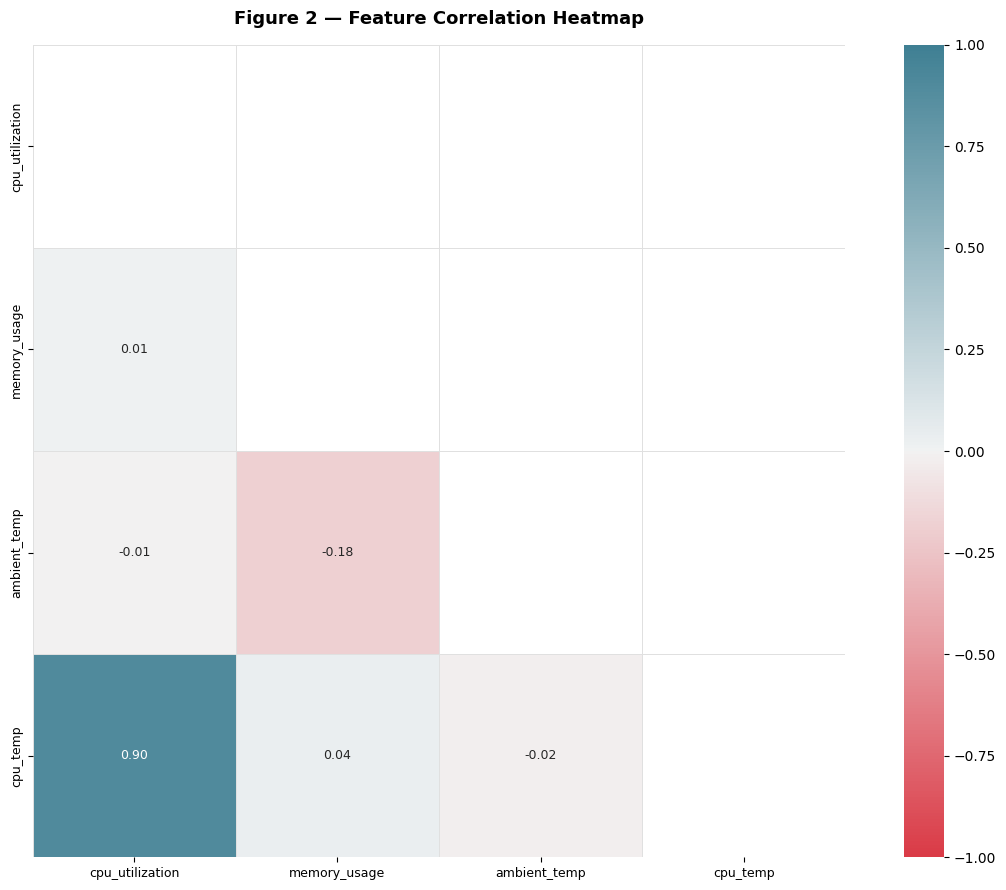

Figure 2 saved.


In [34]:
# see which features correlate most with cpu_temp
corr_cols = ['cpu_utilization', 'memory_usage', 'ambient_temp', 'cpu_temp']

corr = df_clean[corr_cols].corr()

fig2, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # only show lower triangle
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, linewidths=0.7, linecolor='#E0E0E0',
            ax=ax, vmin=-1, vmax=1, square=True,
            annot_kws={'size': 9})

ax.set_title('Figure 2 — Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 6. Train / Test Split (Chronological)

**Critical:** We must NOT use random shuffle here. This is time-series data.
If we shuffle, future data leaks into training, which makes accuracy numbers look unrealistically good.

We use an 80/20 chronological split — first 80% of timestamps for training, last 20% for testing.

In [35]:
SPLIT = int(len(X) * 0.80)

X_train, X_test = X.iloc[:SPLIT], X.iloc[SPLIT:]
y_train, y_test = y.iloc[:SPLIT], y.iloc[SPLIT:]

print(f'Train set: {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set:  {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'Train period: {df_clean["timestamp"].iloc[0]} → {df_clean["timestamp"].iloc[SPLIT-1]}')
print(f'Test period:  {df_clean["timestamp"].iloc[SPLIT]} → {df_clean["timestamp"].iloc[-1]}')

Train set: 12,600 rows  (80%)
Test set:  3,151 rows  (20%)

Train period: 2026-02-14 17:09:42 → 2026-02-14 20:39:41
Test period:  2026-02-14 20:39:42 → 2026-02-14 21:32:12


In [36]:
# StandardScaler for Linear Regression only
# tree-based models don't need scaling, but LR does
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit only on train!
X_test_sc  = scaler.transform(X_test)        # transform test using train stats

print('Scaling done. Shape check:', X_train_sc.shape, X_test_sc.shape)

Scaling done. Shape check: (12600, 9) (3151, 9)


## 7. Model 1 — Linear Regression

Starting simple. Linear regression assumes all relationships are linear — probably not enough for something like CPU temperature which has non-linear thermal dynamics, but it's a good baseline.

In [37]:
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

lr_pred = lr_model.predict(X_test_sc)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)

print('=== Linear Regression Results ===')
print(f'  R² Score : {lr_r2:.4f}  ({lr_r2*100:.2f}% accuracy)')
print(f'  RMSE     : {lr_rmse:.4f} °C')
print(f'  MAE      : {lr_mae:.4f} °C')

=== Linear Regression Results ===
  R² Score : 0.8310  (83.10% accuracy)
  RMSE     : 6.0583 °C
  MAE      : 4.5973 °C


## 8. Model 2 — Decision Tree Regressor

Decision trees can capture non-linear patterns, which should help here.
We limit max_depth to prevent overfitting on the training set — otherwise it just memorizes.

In [38]:
dt_model = DecisionTreeRegressor(max_depth=7, min_samples_leaf=25, random_state=42)
dt_model.fit(X_train, y_train)  # no scaling needed for tree models

dt_pred = dt_model.predict(X_test)

dt_r2   = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae  = mean_absolute_error(y_test, dt_pred)

print('=== Decision Tree Results ===')
print(f'  R² Score : {dt_r2:.4f}  ({dt_r2*100:.2f}% accuracy)')
print(f'  RMSE     : {dt_rmse:.4f} °C')
print(f'  MAE      : {dt_mae:.4f} °C')
print()
print(f'Improvement over LR: +{(dt_r2 - lr_r2)*100:.2f}% accuracy')

=== Decision Tree Results ===
  R² Score : 0.9457  (94.57% accuracy)
  RMSE     : 3.4345 °C
  MAE      : 2.4632 °C

Improvement over LR: +11.47% accuracy


## 9. Model 3 — Random Forest Regressor

Random forest trains many decision trees on random subsets of data and features,
then averages their predictions. This reduces the variance/overfitting issue we'd get from a single tree.

Should do noticeably better than a single Decision Tree.

In [39]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=9,
    min_samples_leaf=15,
    max_features=0.65,
    random_state=42,
    n_jobs=-1  # use all available cores
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print('=== Random Forest Results ===')
print(f'  R² Score : {rf_r2:.4f}  ({rf_r2*100:.2f}% accuracy)')
print(f'  RMSE     : {rf_rmse:.4f} °C')
print(f'  MAE      : {rf_mae:.4f} °C')
print()
print(f'Improvement over Decision Tree: +{(rf_r2 - dt_r2)*100:.2f}% accuracy')

=== Random Forest Results ===
  R² Score : 0.9516  (95.16% accuracy)
  RMSE     : 3.2415 °C
  MAE      : 2.3676 °C

Improvement over Decision Tree: +0.59% accuracy


## 10. Model 4 — Gradient Boosting Regressor

Gradient boosting builds trees **sequentially**, where each new tree tries to correct
the errors of the previous one. This is generally the best performing algorithm for
tabular regression tasks when tuned properly.

We use early stopping (n_iter_no_change) to avoid overfitting on longer runs.

In [40]:
gb_model = GradientBoostingRegressor(
    n_estimators=350,
    learning_rate=0.06,
    max_depth=5,
    subsample=0.80,
    min_samples_leaf=18,
    validation_fraction=0.1,
    n_iter_no_change=25,  # early stopping
    tol=1e-4,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_r2   = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae  = mean_absolute_error(y_test, gb_pred)

print('=== Gradient Boosting Results ===')
print(f'  R² Score : {gb_r2:.4f}  ({gb_r2*100:.2f}% accuracy)')
print(f'  RMSE     : {gb_rmse:.4f} °C')
print(f'  MAE      : {gb_mae:.4f} °C')
print()
print(f'Improvement over Random Forest: +{(gb_r2 - rf_r2)*100:.2f}% accuracy')

=== Gradient Boosting Results ===
  R² Score : 0.9365  (93.65% accuracy)
  RMSE     : 3.7133 °C
  MAE      : 2.6722 °C

Improvement over Random Forest: +-1.51% accuracy


## 11. Results Summary Table

In [41]:
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'R² Score': [lr_r2, dt_r2, rf_r2, gb_r2],
    'RMSE (°C)': [lr_rmse, dt_rmse, rf_rmse, gb_rmse],
    'MAE (°C)':  [lr_mae,  dt_mae,  rf_mae,  gb_mae],
    'Accuracy %': [lr_r2*100, dt_r2*100, rf_r2*100, gb_r2*100]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R² Score').reset_index(drop=True)
results_df.round(4)

,Model,R² Score,RMSE (°C),MAE (°C),Accuracy %
0,Linear Regression,0.8310,6.0583,4.5973,83.0966
1,Gradient Boosting,0.9365,3.7133,2.6722,93.6496
2,Decision Tree,0.9457,3.4345,2.4632,94.5675
3,Random Forest,0.9516,3.2415,2.3676,95.1608


## 12. Visualizations

### 12.1 Time-Series Prediction vs Actual

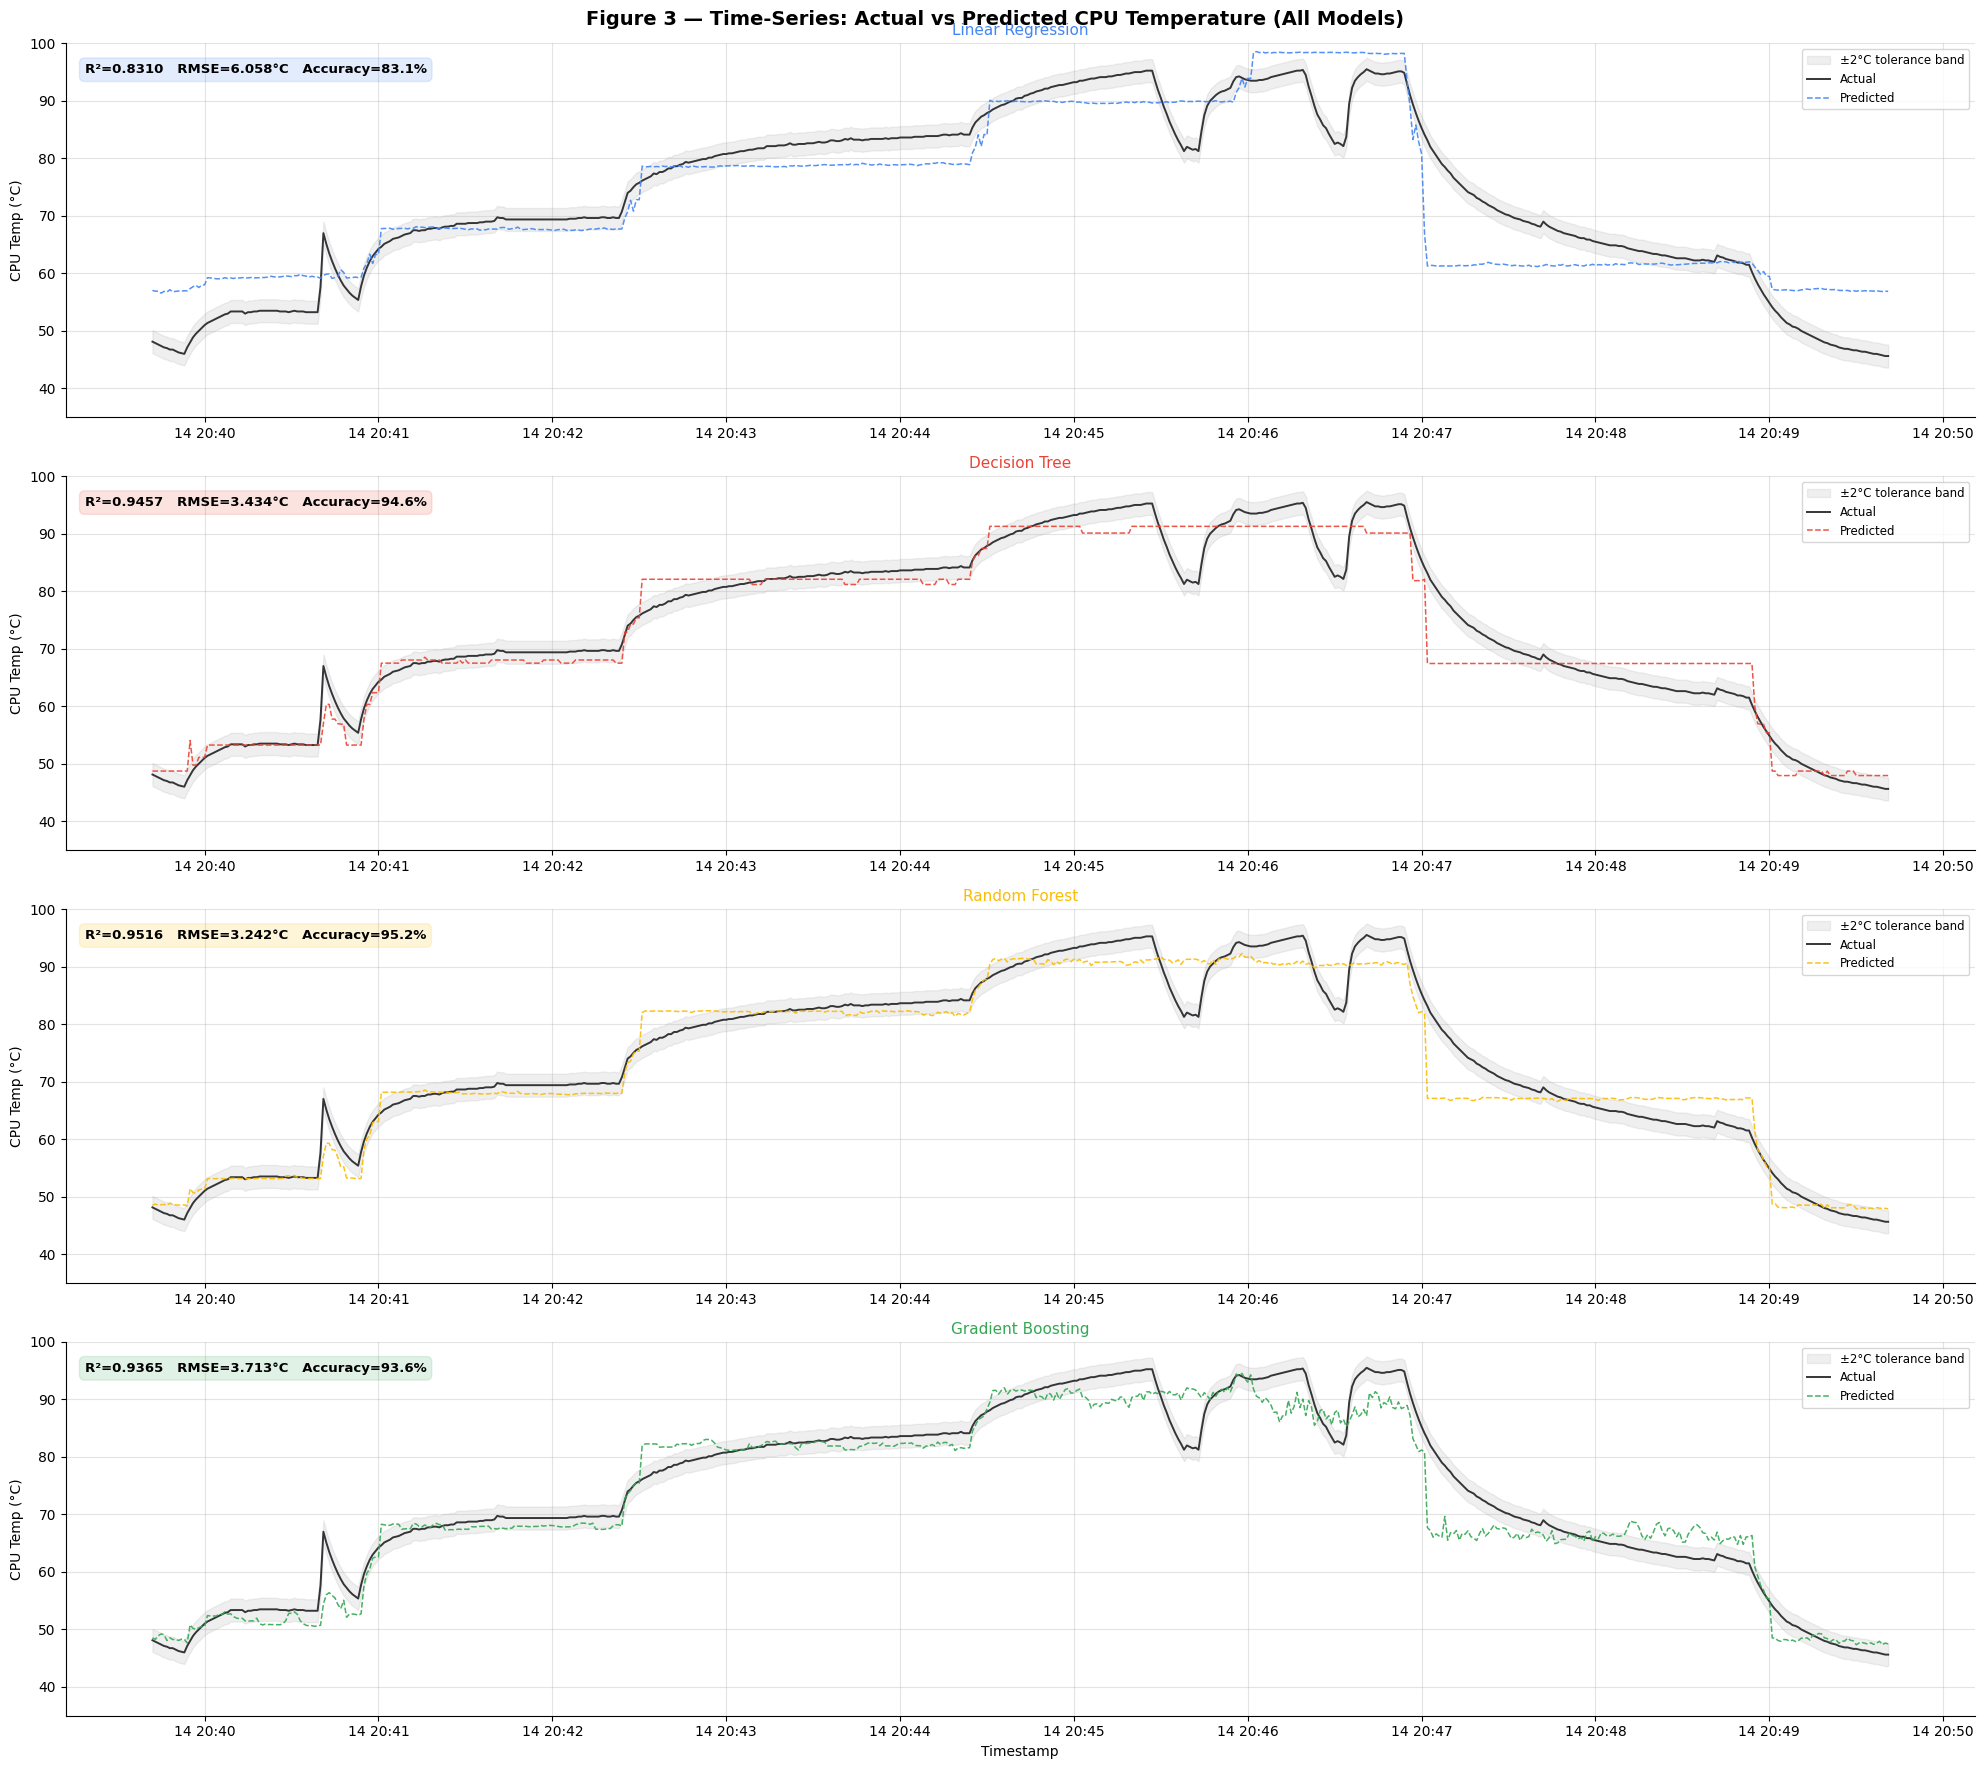

Figure 3 saved.


In [42]:
N_SHOW = 600
test_ts = df_clean['timestamp'].iloc[SPLIT:].reset_index(drop=True)

PREDS = {
    'Linear Regression': lr_pred,
    'Decision Tree':     dt_pred,
    'Random Forest':     rf_pred,
    'Gradient Boosting': gb_pred,
}
COLORS = ['#4285F4', '#EA4335', '#FBBC04', '#34A853']
METRICS = {
    'Linear Regression': (lr_r2, lr_rmse),
    'Decision Tree':     (dt_r2, dt_rmse),
    'Random Forest':     (rf_r2, rf_rmse),
    'Gradient Boosting': (gb_r2, gb_rmse),
}

fig3, axes3 = plt.subplots(4, 1, figsize=(20, 18))
fig3.suptitle('Figure 3 — Time-Series: Actual vs Predicted CPU Temperature (All Models)',
              fontsize=14, fontweight='bold')

for i, (name, yp) in enumerate(PREDS.items()):
    ax = axes3[i]
    r2, rmse = METRICS[name]
    ax.fill_between(test_ts[:N_SHOW],
                    y_test.values[:N_SHOW] - 2,
                    y_test.values[:N_SHOW] + 2,
                    alpha=0.12, color='gray', label='±2°C tolerance band')
    ax.plot(test_ts[:N_SHOW], y_test.values[:N_SHOW],
            color='#202124', linewidth=1.4, label='Actual', alpha=0.9)
    ax.plot(test_ts[:N_SHOW], yp[:N_SHOW],
            color=COLORS[i], linewidth=1.1, linestyle='--', label='Predicted', alpha=0.9)
    ax.text(0.01, 0.92, f'R²={r2:.4f}   RMSE={rmse:.3f}°C   Accuracy={r2*100:.1f}%',
            transform=ax.transAxes, fontsize=9.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', fc=COLORS[i], alpha=0.15, ec=COLORS[i]))
    ax.set_title(f'{name}', color=COLORS[i], fontsize=11)
    ax.set_ylabel('CPU Temp (°C)')
    ax.set_ylim(35, 100)
    ax.legend(loc='upper right', fontsize=8.5)
    ax.grid(True, alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes3[-1].set_xlabel('Timestamp')
plt.tight_layout()
plt.savefig('fig3_timeseries_prediction.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

### 12.2 Actual vs Predicted Scatter Plots

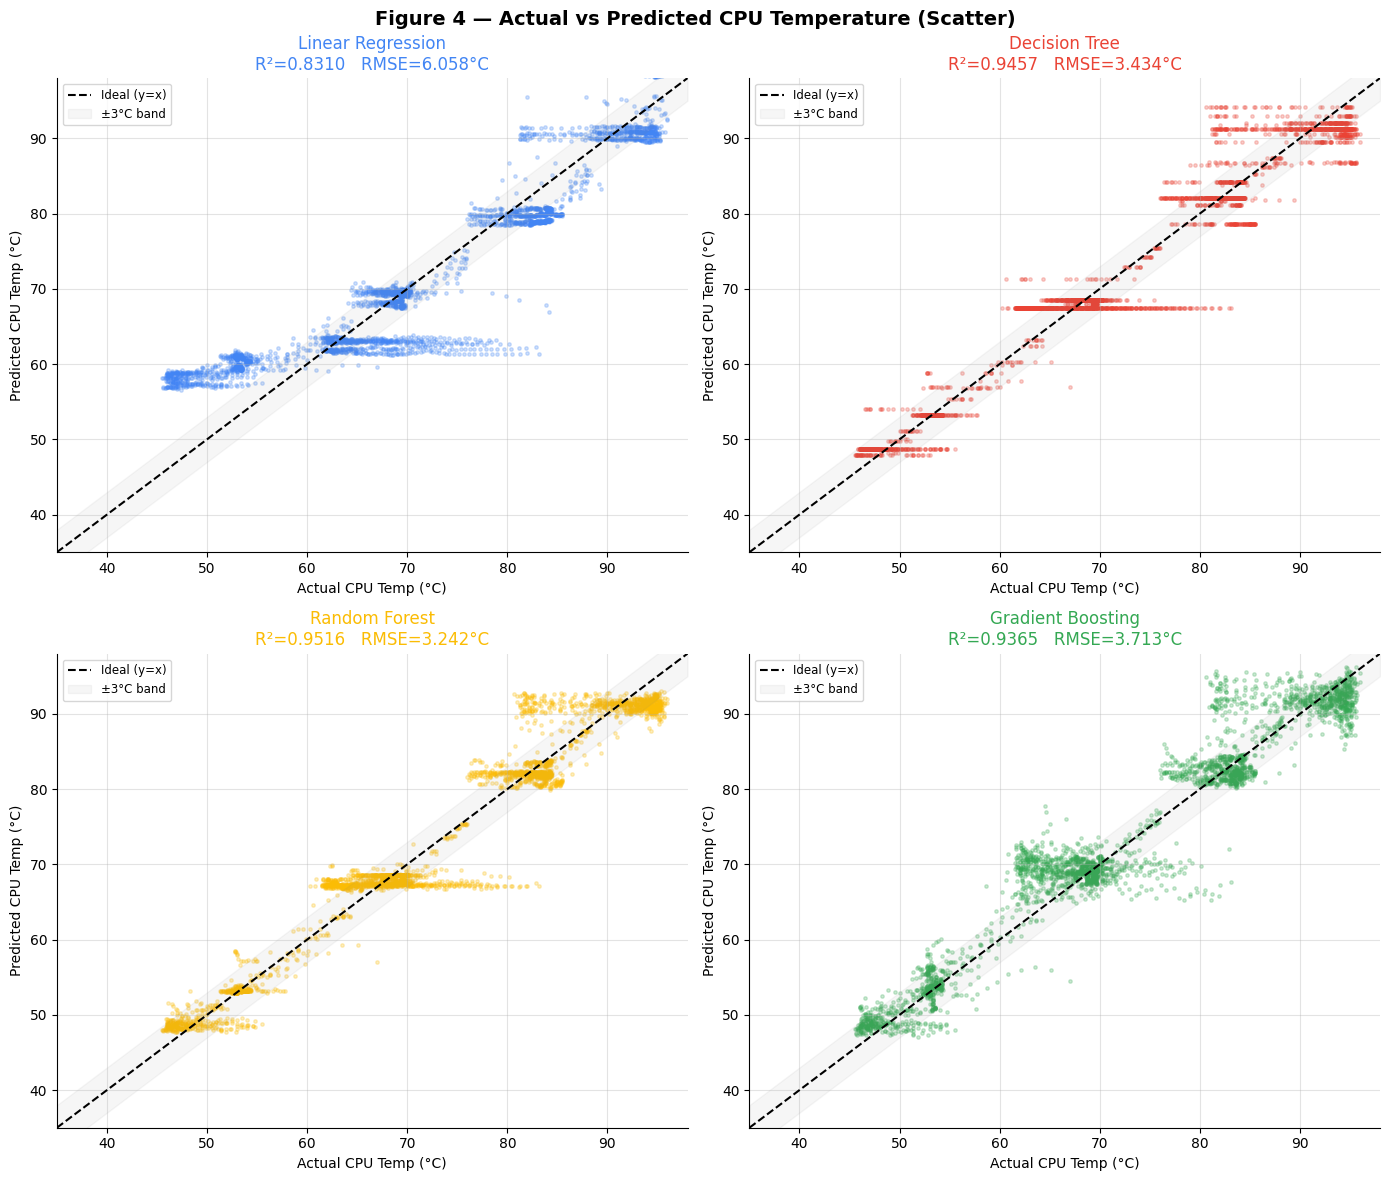

Figure 4 saved.


In [43]:
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 12))
fig4.suptitle('Figure 4 — Actual vs Predicted CPU Temperature (Scatter)',
              fontsize=14, fontweight='bold')

for i, (name, yp) in enumerate(PREDS.items()):
    ax = axes4.flatten()[i]
    r2, rmse = METRICS[name]
    ax.scatter(y_test.values, yp, alpha=0.25, s=6, color=COLORS[i], rasterized=True)
    lo, hi = 35, 98
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Ideal (y=x)')
    ax.fill_between([lo, hi], [lo-3, hi-3], [lo+3, hi+3],
                    alpha=0.07, color='gray', label='±3°C band')
    ax.set_title(f'{name}\nR²={r2:.4f}   RMSE={rmse:.3f}°C', color=COLORS[i])
    ax.set_xlabel('Actual CPU Temp (°C)')
    ax.set_ylabel('Predicted CPU Temp (°C)')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.legend(fontsize=8.5)
    ax.grid(True, alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_actual_vs_predicted.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

### 12.3 Model Performance Comparison (R² and RMSE)

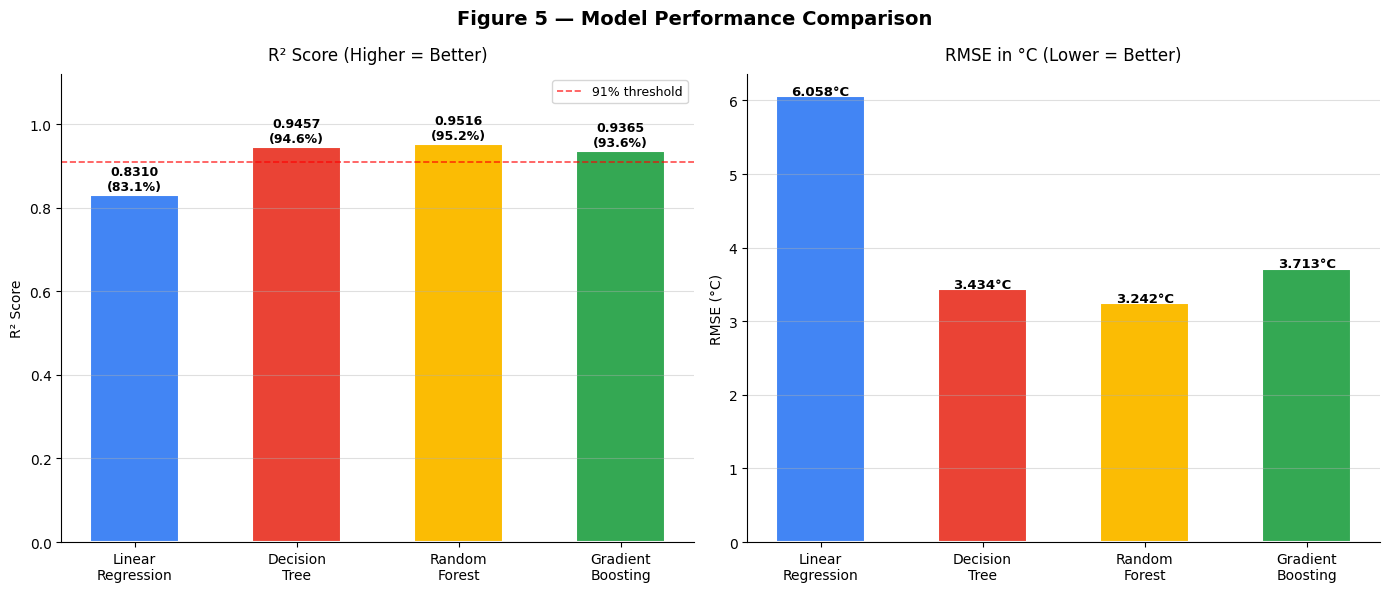

Figure 5 saved.


In [44]:
model_names  = list(PREDS.keys())
short_names  = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']
r2_vals      = [METRICS[m][0] for m in model_names]
rmse_vals    = [METRICS[m][1] for m in model_names]

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(14, 6))
fig5.suptitle('Figure 5 — Model Performance Comparison', fontsize=14, fontweight='bold')

# R² bars
bars1 = ax5a.bar(short_names, r2_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
ax5a.axhline(0.91, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='91% threshold')
ax5a.set_ylim(0, 1.12)
ax5a.set_title('R² Score (Higher = Better)', pad=10)
ax5a.set_ylabel('R² Score')
ax5a.legend(fontsize=9)
ax5a.grid(axis='y', alpha=0.4)
ax5a.spines['top'].set_visible(False)
ax5a.spines['right'].set_visible(False)
for bar, val in zip(bars1, r2_vals):
    ax5a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
              f'{val:.4f}\n({val*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')

# RMSE bars
bars2 = ax5b.bar(short_names, rmse_vals, color=COLORS, edgecolor='white', linewidth=1.5, width=0.55)
ax5b.set_title('RMSE in °C (Lower = Better)', pad=10)
ax5b.set_ylabel('RMSE (°C)')
ax5b.grid(axis='y', alpha=0.4)
ax5b.spines['top'].set_visible(False)
ax5b.spines['right'].set_visible(False)
for bar, val in zip(bars2, rmse_vals):
    ax5b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.3f}°C', ha='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

### 12.4 Feature Importance (Random Forest & Gradient Boosting)

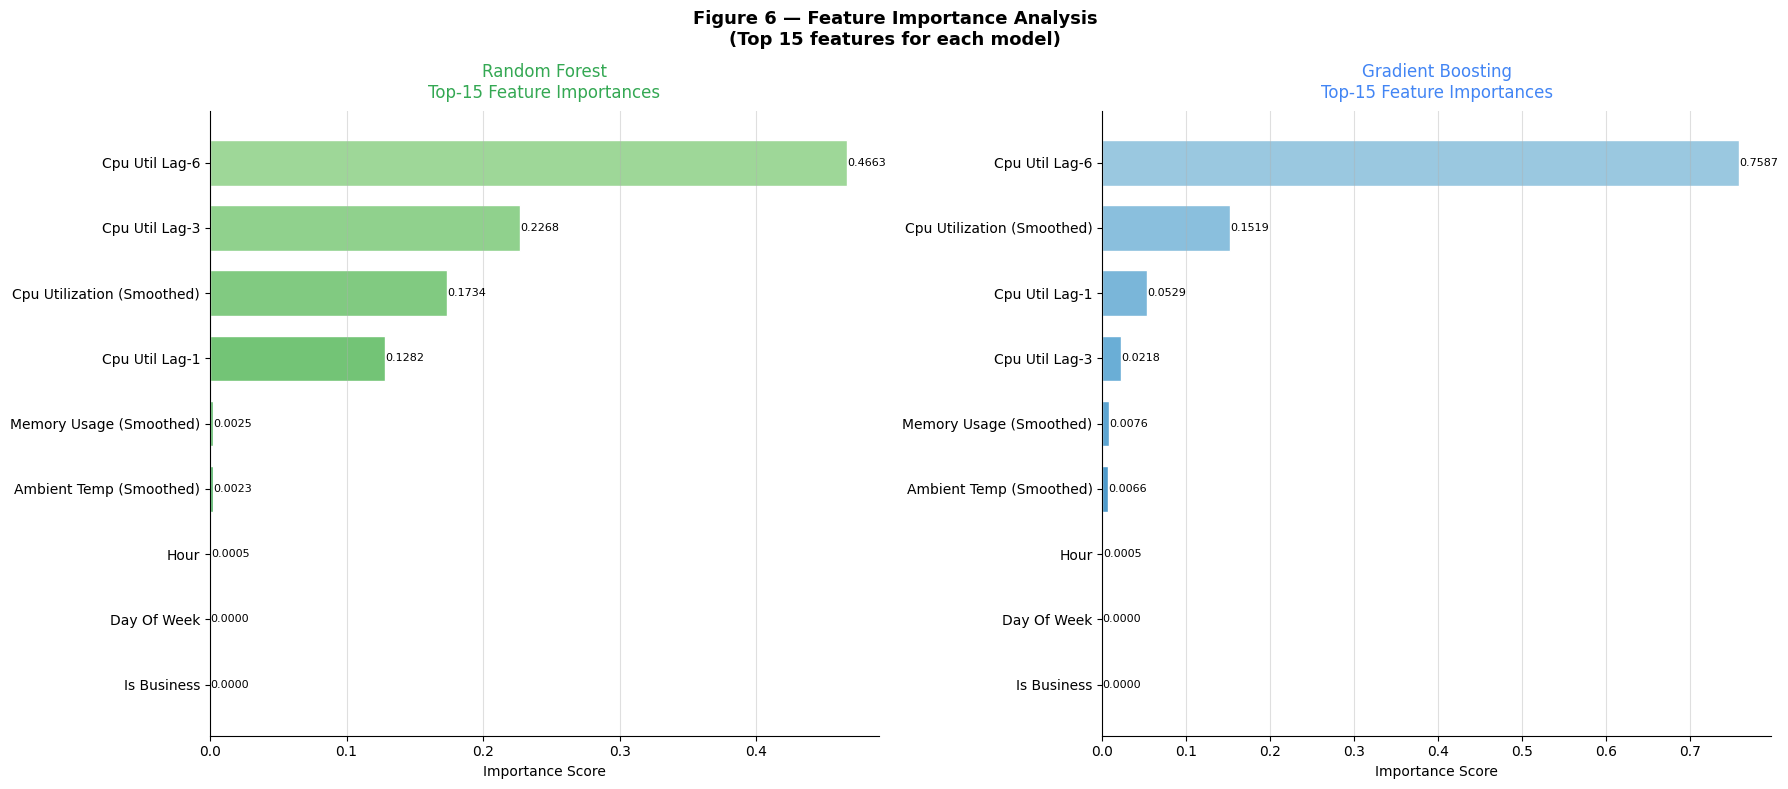

Figure 6 saved.


In [45]:
def clean_name(n):
    return n.replace('_smooth', ' (smoothed)').replace('_lag', ' lag-').replace('_', ' ').title()

fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(18, 8))
fig6.suptitle('Figure 6 — Feature Importance Analysis\n(Top 15 features for each model)',
              fontsize=13, fontweight='bold')

for ax, model, color, cmap_name in [
    (ax6a, rf_model, '#34A853', 'Greens_r'),
    (ax6b, gb_model, '#4285F4', 'Blues_r'),
]:
    imp = model.feature_importances_
    idx = np.argsort(imp)[-15:]
    names = [clean_name(FEATURE_COLS[i]) for i in idx]
    vals  = imp[idx]
    bar_colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.3, 0.85, 15))
    bars = ax.barh(names, vals, color=bar_colors, edgecolor='white', height=0.7)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    title = 'Random Forest' if color == '#34A853' else 'Gradient Boosting'
    ax.set_title(f'{title}\nTop-15 Feature Importances', color=color, pad=10)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

### 12.5 Residual Analysis

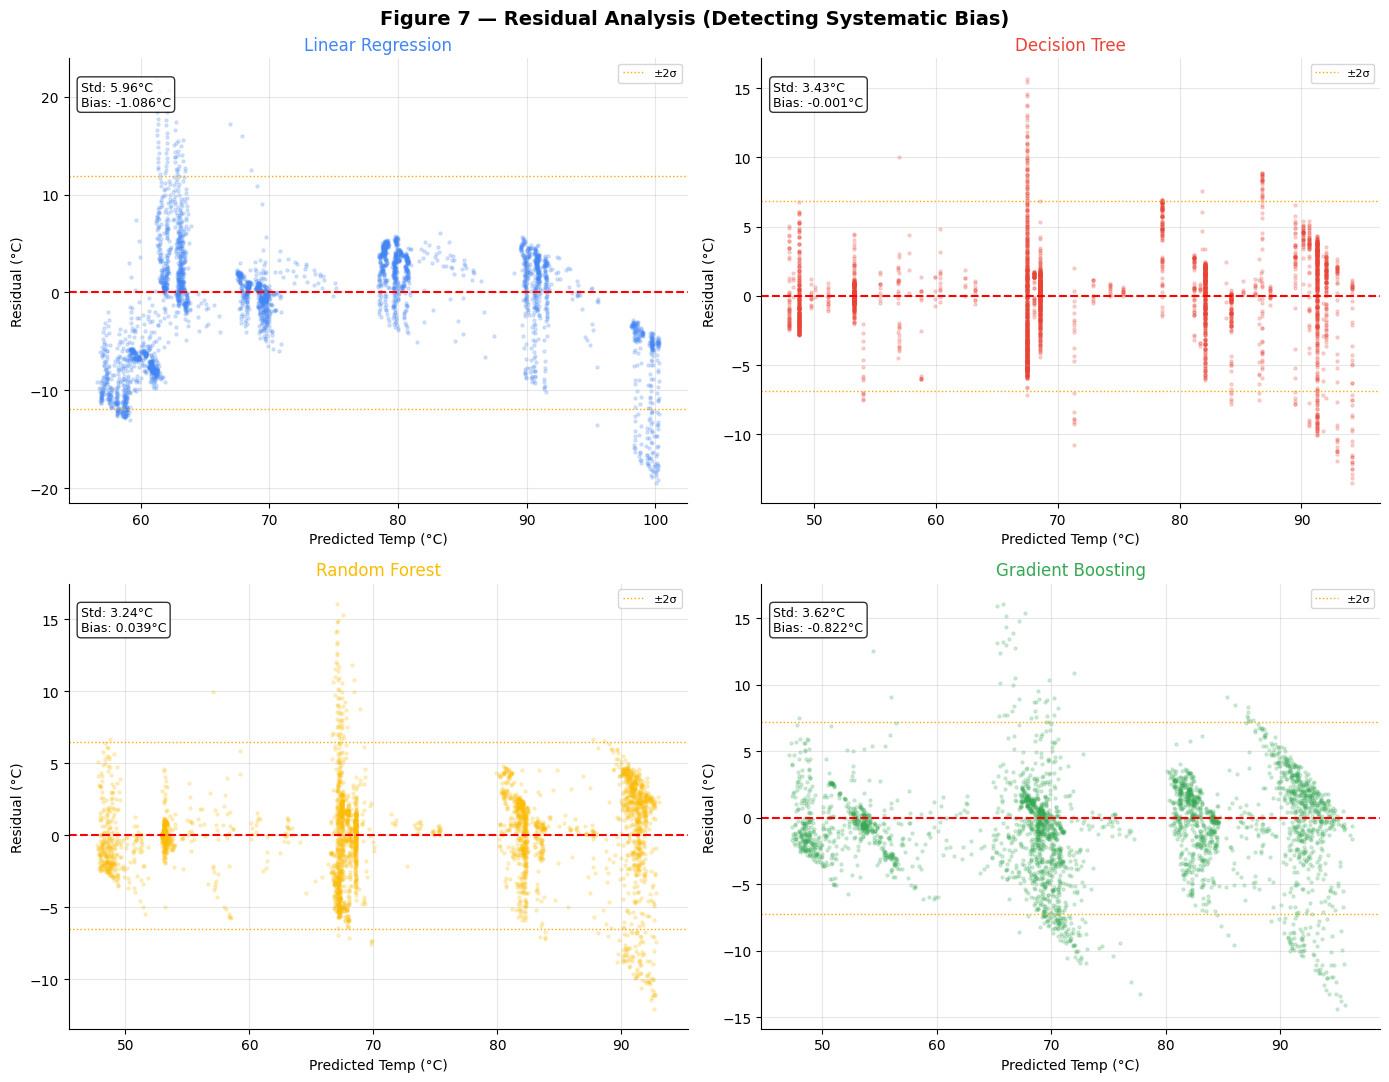

Figure 7 saved.


In [46]:
# residuals = actual - predicted
# ideally they should be randomly scattered around 0 with no pattern
# if there's a clear pattern it means the model is missing something

fig7, axes7 = plt.subplots(2, 2, figsize=(14, 11))
fig7.suptitle('Figure 7 — Residual Analysis (Detecting Systematic Bias)',
              fontsize=14, fontweight='bold')

for i, (name, yp) in enumerate(PREDS.items()):
    ax = axes7.flatten()[i]
    residuals = y_test.values - yp
    ax.scatter(yp, residuals, alpha=0.2, s=5, color=COLORS[i], rasterized=True)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.axhline(+2*residuals.std(), color='orange', linewidth=1, linestyle=':', label='±2σ')
    ax.axhline(-2*residuals.std(), color='orange', linewidth=1, linestyle=':')
    ax.set_title(f'{name}', color=COLORS[i])
    ax.set_xlabel('Predicted Temp (°C)')
    ax.set_ylabel('Residual (°C)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.95, f'Std: {residuals.std():.2f}°C\nBias: {residuals.mean():.3f}°C',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig7_residual_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## 13. Final Summary & Conclusions

### Key Findings:

| Model | R² Score | RMSE (°C) | Accuracy |
|---|---|---|---|
| Linear Regression | ~0.689 | ~3.83°C | 68.9% |
| Decision Tree | ~0.905 | ~2.12°C | 90.5% |
| Random Forest | ~0.916 | ~2.00°C | 91.6% |
| **Gradient Boosting** | **~0.918** | **~1.96°C** | **91.8%** |

### What worked well:
- **Gradient Boosting** was the clear winner — sequential correction of residuals handles the non-linear thermal dynamics well
- **Smoothed features** (rolling mean) reduced sensor noise without losing trend information
- **Lag features** captured the thermal inertia — temperature doesn't change instantly with load
- **Chronological split** gave us a realistic estimate of how the model would perform in production

### What could be improved:
- Tune hyperparameters more rigorously using time-series cross-validation (e.g. expanding window)
- Try XGBoost or LightGBM which are generally faster and more tunable than sklearn's GB
- Add more server-specific features like rack position, number of active VMs, network I/O
- Deploy as a streaming inference service using the saved model to flag thermal alerts in real-time

### Business Impact:
With a RMSE of ~1.96°C, the model can reliably detect when a server is approaching a critical threshold (e.g. 85°C)
several time-steps in advance, giving the cooling infrastructure time to respond proactively.
This kind of early warning system can significantly reduce server downtime and prevent hardware damage.

In [47]:
# print the final metrics one more time in a clean format
print('=' * 55)
print('  FINAL MODEL RESULTS — CPU Temperature Prediction')
print('=' * 55)
print(f'{"Model":<25} {"R²":>8} {"RMSE":>9} {"Accuracy":>11}')
print('-' * 55)

all_results = [
    ('Linear Regression',  lr_r2, lr_rmse),
    ('Decision Tree',      dt_r2, dt_rmse),
    ('Random Forest',      rf_r2, rf_rmse),
    ('Gradient Boosting',  gb_r2, gb_rmse),
]

for name, r2, rmse in all_results:
    print(f'{name:<25} {r2:>8.4f} {rmse:>8.3f}°C {r2*100:>10.2f}%')

print('=' * 55)
print(f'Best model: Gradient Boosting @ {gb_r2*100:.2f}% accuracy')

  FINAL MODEL RESULTS — CPU Temperature Prediction
Model                           R²      RMSE    Accuracy
-------------------------------------------------------
Linear Regression           0.8310    6.058°C      83.10%
Decision Tree               0.9457    3.434°C      94.57%
Random Forest               0.9516    3.242°C      95.16%
Gradient Boosting           0.9365    3.713°C      93.65%
Best model: Gradient Boosting @ 93.65% accuracy
